# 의료시설 + 건물 필터링 격자 통합 시각화

`load_medical_facilities.ipynb`의 의료시설 포인트(`medical_facilities_filtered`)와
`filter_grid_by_buildings.ipynb`의 건물 존재 격자(`grid_100m_daegugyeongbuk_with_buildings`)를
하나의 지도에 겹쳐서, 접근성 계산에 쓰일 두 축(수요=격자, 공급=의료시설)의 공간적 관계를 확인한다.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

## 데이터 로드

세 레이어 모두 EPSG:5179로 통일한다.

In [2]:
grid_bldg = gpd.read_file(
    "data/grid_100m_daegugyeongbuk_with_buildings/grid_100m_daegugyeongbuk_with_buildings.shp",
    encoding="cp949",
)
facilities = gpd.read_file(
    "data/medical_facilities_filtered/medical_facilities_filtered.shp", encoding="cp949"
)

sigungu = gpd.read_file("data/BND_SIGUNGU_PG/BND_SIGUNGU_PG.shp", encoding="cp949")
target_codes = [
    "22010", "22020", "22030", "22040", "22050", "22060", "22070", "22510", "22520",  # 대구
    "37050", "37030", "37070", "37100",  # 구미, 김천, 영천, 경산
    "37560", "37570", "37580", "37590",  # 청도, 고령, 성주, 칠곡
]
target_sigungu = sigungu[sigungu["SIGUNGU_CD"].isin(target_codes)].to_crs(grid_bldg.crs)

print(f"건물 존재 격자: {len(grid_bldg)}개 (CRS={grid_bldg.crs})")
print(f"의료시설 포인트: {len(facilities)}개 (CRS={facilities.crs})")

# 연구 대상 지역 내 의료시설만 사용
facilities_in_target = gpd.sjoin(
    facilities, target_sigungu[["SIGUNGU_NM", "geometry"]], how="inner", predicate="within"
)
print(f"대상 지역 내 의료시설: {len(facilities_in_target)}개")

건물 존재 격자: 144528개 (CRS=EPSG:5179)
의료시설 포인트: 43014개 (CRS=EPSG:5179)
대상 지역 내 의료시설: 3039개


## 시각화

건물 존재 격자(옅은 주황, 접근성 계산의 "수요" 대상)와 의료시설 포인트(종별 색상 구분, "공급")를 시군구 경계 위에 함께 표시한다.

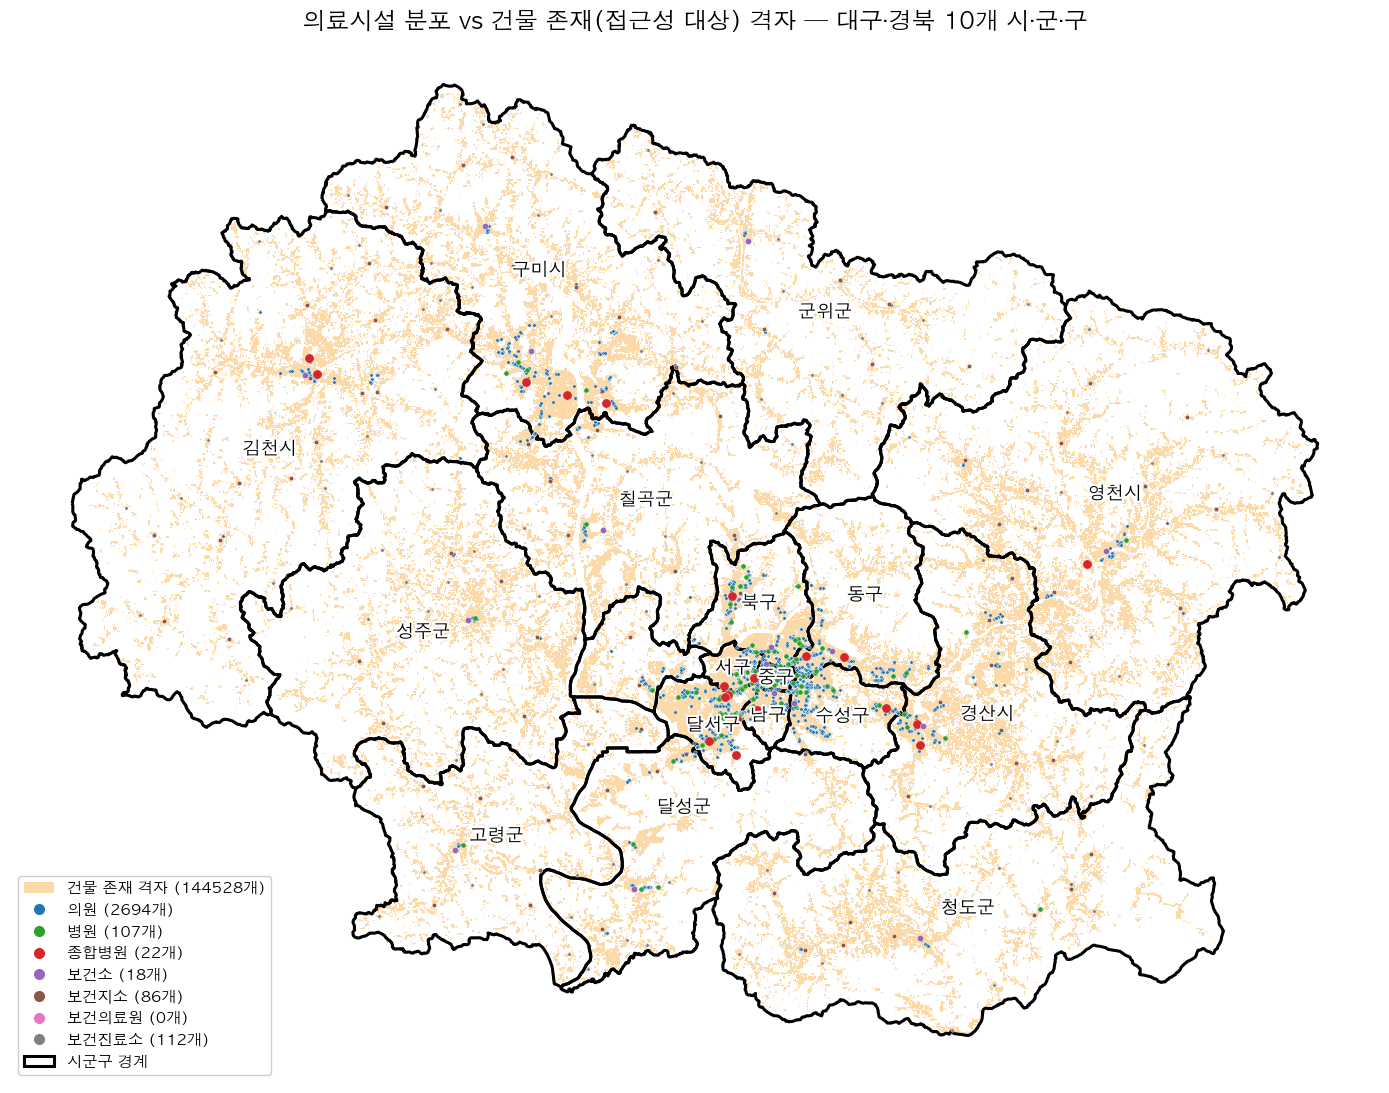

In [3]:
FAC_TYPES = ["의원", "병원", "종합병원", "보건소", "보건지소", "보건의료원", "보건진료소"]
FAC_COLORS = ["#1f77b4", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f"]
FAC_SIZES = {"의원": 6, "병원": 14, "종합병원": 45, "보건소": 20, "보건지소": 10,
             "보건의료원": 20, "보건진료소": 6}

fig, ax = plt.subplots(figsize=(14, 14))

# 1) 건물 존재 격자 — 옅은 주황 배경 (수요 대상 지역)
grid_bldg.plot(ax=ax, color="#fcd9a8", edgecolor="none", zorder=1,
               label=f"건물 존재 격자 ({len(grid_bldg)}개)")

# 2) 시군구 경계
target_sigungu.boundary.plot(ax=ax, color="black", linewidth=2.2, zorder=2)

# 3) 의료시설 — 종별 색상·크기 구분 (공급 지점)
for t, color in zip(FAC_TYPES, FAC_COLORS):
    sub = facilities_in_target[facilities_in_target["FAC_TYPE"] == t]
    ax.scatter(sub.geometry.x, sub.geometry.y, s=FAC_SIZES[t], color=color,
               edgecolor="white", linewidth=0.3, zorder=3, label=f"{t} ({len(sub)}개)")

# 4) 시군구 라벨
for _, row in target_sigungu.iterrows():
    c = row.geometry.centroid
    ax.annotate(
        row["SIGUNGU_NM"], xy=(c.x, c.y), ha="center", va="center",
        fontsize=13, fontweight="bold", color="black", zorder=4,
        path_effects=[pe.withStroke(linewidth=3, foreground="white")],
    )

legend_elements = [Patch(facecolor="#fcd9a8", label=f"건물 존재 격자 ({len(grid_bldg)}개)")]
legend_elements += [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=color,
           markeredgecolor="white", markersize=9, label=f"{t} ({(facilities_in_target['FAC_TYPE']==t).sum()}개)")
    for t, color in zip(FAC_TYPES, FAC_COLORS)
]
legend_elements.append(Patch(facecolor="none", edgecolor="black", linewidth=2.2, label="시군구 경계"))
ax.legend(handles=legend_elements, loc="lower left", fontsize=11, framealpha=0.95)

ax.set_title("의료시설 분포 vs 건물 존재(접근성 대상) 격자 — 대구·경북 10개 시·군·구", fontsize=17, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("data/medical_facilities_filtered/facilities_and_grid_combined.png", dpi=200)
plt.show()